Message file Columns:
	
	    1.) Time: 		
				Seconds after midnight with decimal 
				precision of at least milliseconds 
				and up to nanoseconds depending on 
				the requested period
	    2.) Type:
				1: Submission of a new limit order
				2: Cancellation (Partial deletion 
				   of a limit order)
				3: Deletion (Total deletion of a limit order)
				4: Execution of a visible limit order			   	 
				5: Execution of a hidden limit order
				7: Trading halt indicator 				   
				   (Detailed information below)
	    3.) Order ID: 	
				Unique order reference number 
				(Assigned in order flow)
	    4.) Size: 		
				Number of shares
	    5.) Price: 		
				Dollar price times 10000 
				(i.e., A stock price of $91.14 is given 
				by 911400)
	    6.) Direction:
				-1: Sell limit order
				1: Buy limit order
				
				Note: 
				Execution of a sell (buy) limit
				order corresponds to a buyer (seller) 
				initiated trade, i.e. Buy (Sell) trade.
										
                                        
type 5: [(1, 69946), (3, 63528), (4, 6559), (2, 868), (5, 606)]

direction 2 : [(-1, 72640), (1, 68867)]

In [11]:
# https://lobsterdata.com/info/DataSamples.php

import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from datetime import datetime
import pickle

ddir = "OrderBook"
dirs = os.listdir(ddir)
dirs

['LOBSTER_SampleFile_AAPL_2012-06-21_50.zip',
 'LOBSTER_SampleFile_AMZN_2012-06-21_1',
 'LOBSTER_SampleFile_AMZN_2012-06-21_1.zip',
 'LOBSTER_SampleFile_MSFT_2012-06-21_10.zip',
 'LOBSTER_SampleFile_MSFT_2012-06-21_50',
 'LOBSTER_SampleFile_MSFT_2012-06-21_50.zip',
 'LOBSTER_SampleFile_SPY_2012-06-21_50.zip']

In [12]:
# book file contains the bids and offers in blocks of 4 starting with the nearest to the midmarket
# the 4 values in each block correspond to ask, ask_size, bid, bid_size
# rows are padded with zeros block sizes as needed

print(datetime.now())

dir1 = 'LOBSTER_SampleFile_MSFT_2012-06-21_50'
print(dir1)
sdir = os.path.join(ddir, dir1)
csv_files = [f for f in os.listdir(sdir) if re.search(r'.csv$', f)]
display(csv_files)

book = pd.read_csv(os.path.join(sdir, csv_files[1]), header=None)
display(book)

msg = pd.read_csv(os.path.join(sdir, csv_files[0]), header=None)

msg.columns = ['time','type','orderid','size','price','direction']
display(msg)
print(datetime.now())

2026-03-15 15:43:32.998715
LOBSTER_SampleFile_MSFT_2012-06-21_50


['MSFT_2012-06-21_34200000_37800000_message_50.csv',
 'MSFT_2012-06-21_34200000_37800000_orderbook_50.csv']

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,309900,3788,309500,300,310500,100,309300,3986,310600,100,...,-9999999999,0,9999999999,0,-9999999999,0,9999999999,0,-9999999999,0
1,309900,3788,309500,300,310500,200,309300,3986,310600,100,...,-9999999999,0,9999999999,0,-9999999999,0,9999999999,0,-9999999999,0
2,309900,3788,309500,300,310400,100,309300,3986,310500,200,...,-9999999999,0,9999999999,0,-9999999999,0,9999999999,0,-9999999999,0
3,309900,3788,309500,300,310400,100,309300,3986,310500,300,...,-9999999999,0,9999999999,0,-9999999999,0,9999999999,0,-9999999999,0
4,309900,3788,309500,300,310400,100,309300,3986,310500,300,...,-9999999999,0,9999999999,0,-9999999999,0,9999999999,0,-9999999999,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141502,308500,15930,308400,8789,308600,12473,308300,15196,308700,14603,...,303200,258,313400,150,303100,5000,313500,11500,303000,1400
141503,308500,15930,308400,8459,308600,12473,308300,15196,308700,14603,...,303200,258,313400,150,303100,5000,313500,11500,303000,1400
141504,308500,15930,308400,8459,308600,12473,308300,15196,308700,14523,...,303200,258,313400,150,303100,5000,313500,11500,303000,1400
141505,308500,16010,308400,8459,308600,12473,308300,15196,308700,14523,...,303200,258,313400,150,303100,5000,313500,11500,303000,1400


,time,type,orderid,size,price,direction
0,34200.013994,3,16085616,100,310400,-1
1,34200.013994,1,16116348,100,310500,-1
2,34200.015248,1,16116658,100,310400,-1
3,34200.015442,1,16116704,100,310500,-1
4,34200.015789,1,16116752,100,310600,-1
...,...,...,...,...,...,...
141502,37799.780171,1,74174637,330,308500,-1
141503,37799.781628,3,74163313,330,308400,1
141504,37799.781778,3,74163417,80,308700,-1
141505,37799.781979,1,74175260,80,308500,-1


2026-03-15 15:43:40.049811


In [13]:
from collections import Counter
from datetime import timedelta

display(msg[:3]);display(msg[-3:])
msg_time = [str(timedelta(seconds=t)) for t in msg['time']]

,time,type,orderid,size,price,direction
0,34200.013994,3,16085616,100,310400,-1
1,34200.013994,1,16116348,100,310500,-1
2,34200.015248,1,16116658,100,310400,-1


,time,type,orderid,size,price,direction
141504,37799.781778,3,74163417,80,308700,-1
141505,37799.781979,1,74175260,80,308500,-1
141506,37799.787425,1,74175870,500,308600,-1


In [14]:
book.shape,msg.shape

((141507, 200), (141507, 6))

# plot selected level 2 profiles

range = 8.419999999999998


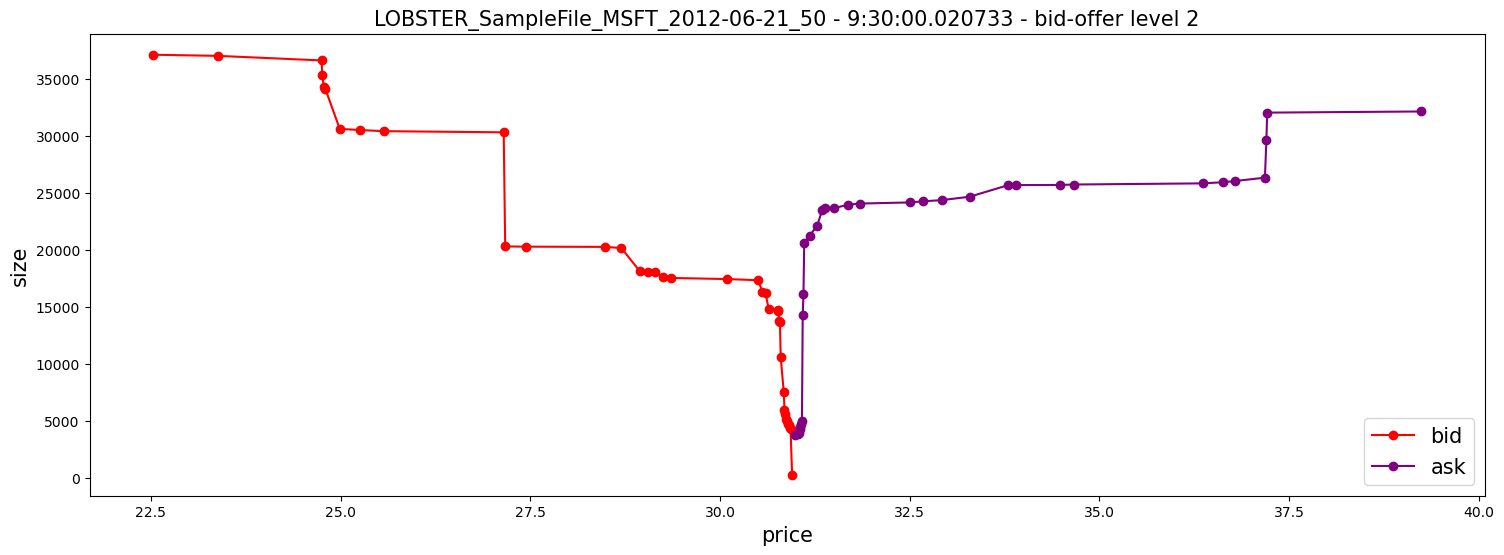

range = 0.5400000000000027


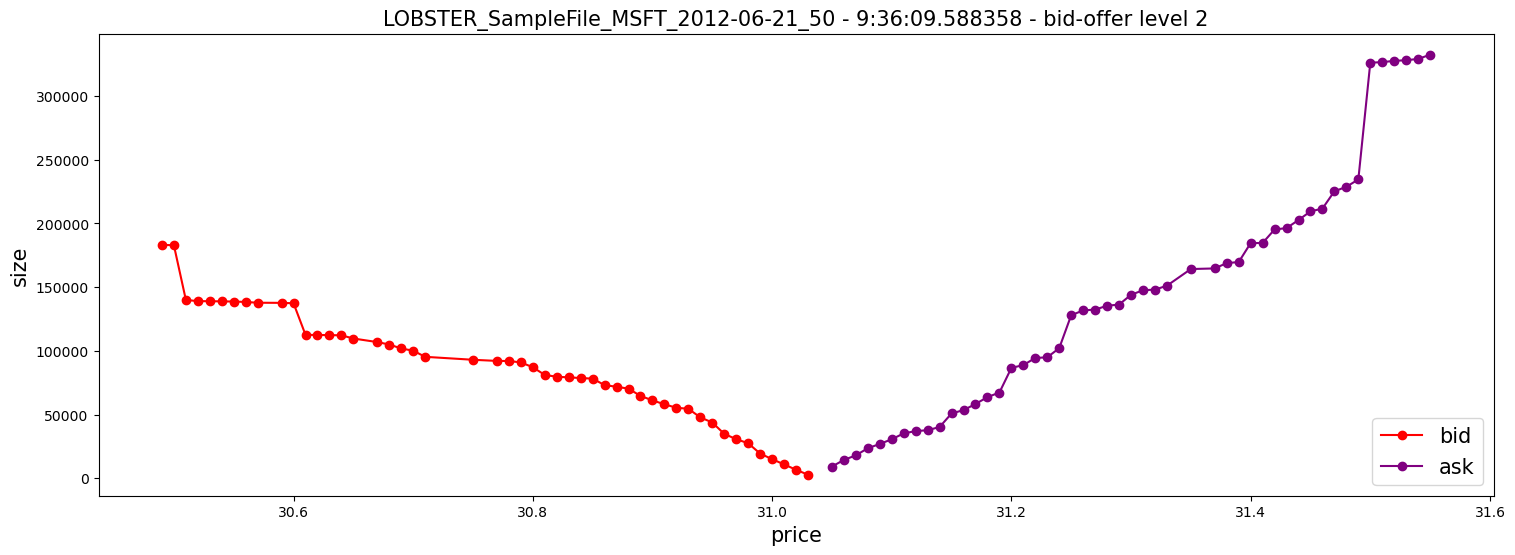

range = 0.48999999999999844


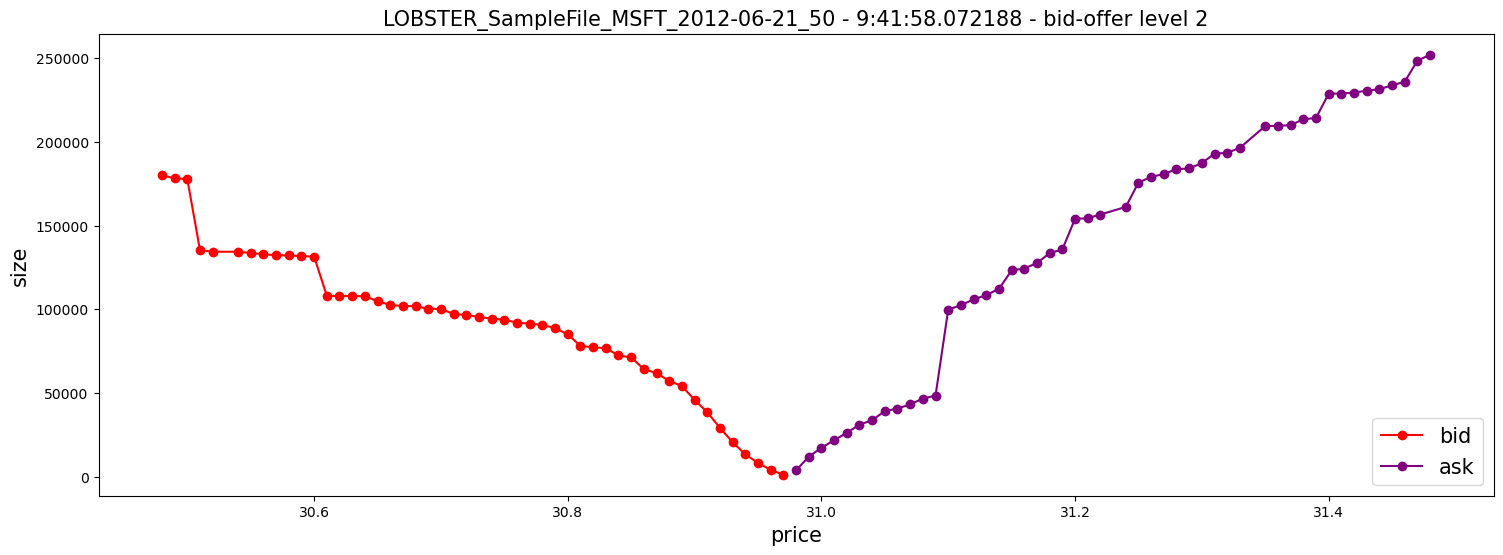

range = 0.5599999999999987


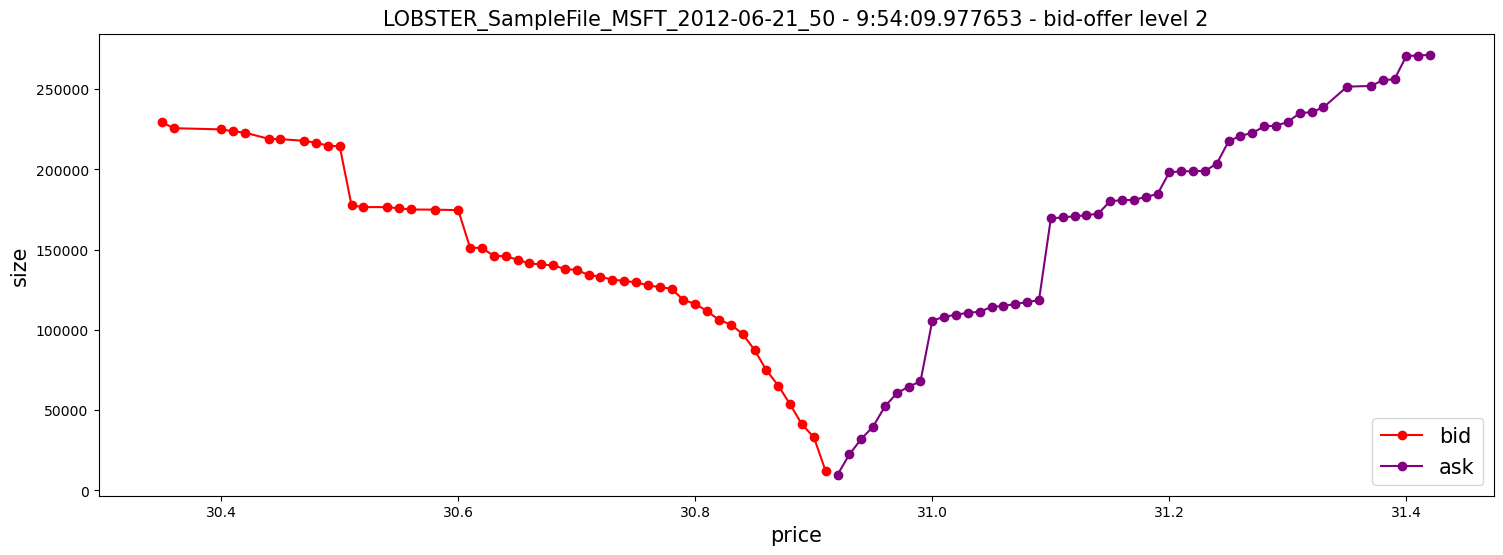

range = 0.5500000000000007


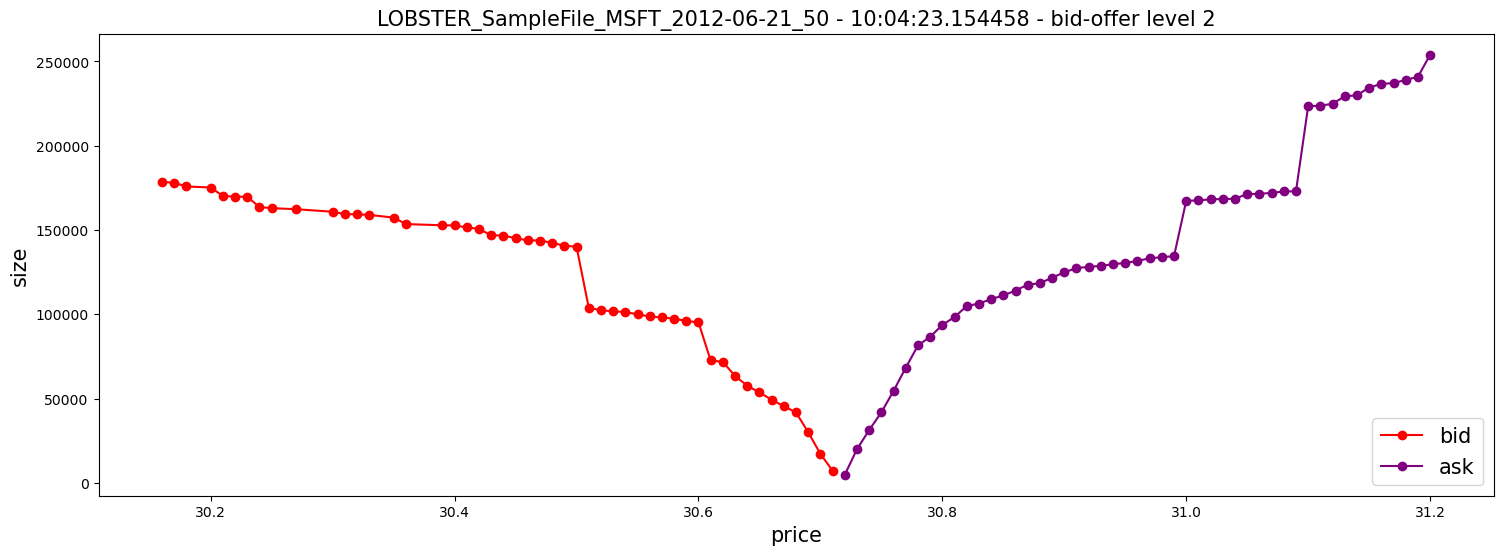

range = 0.5199999999999996


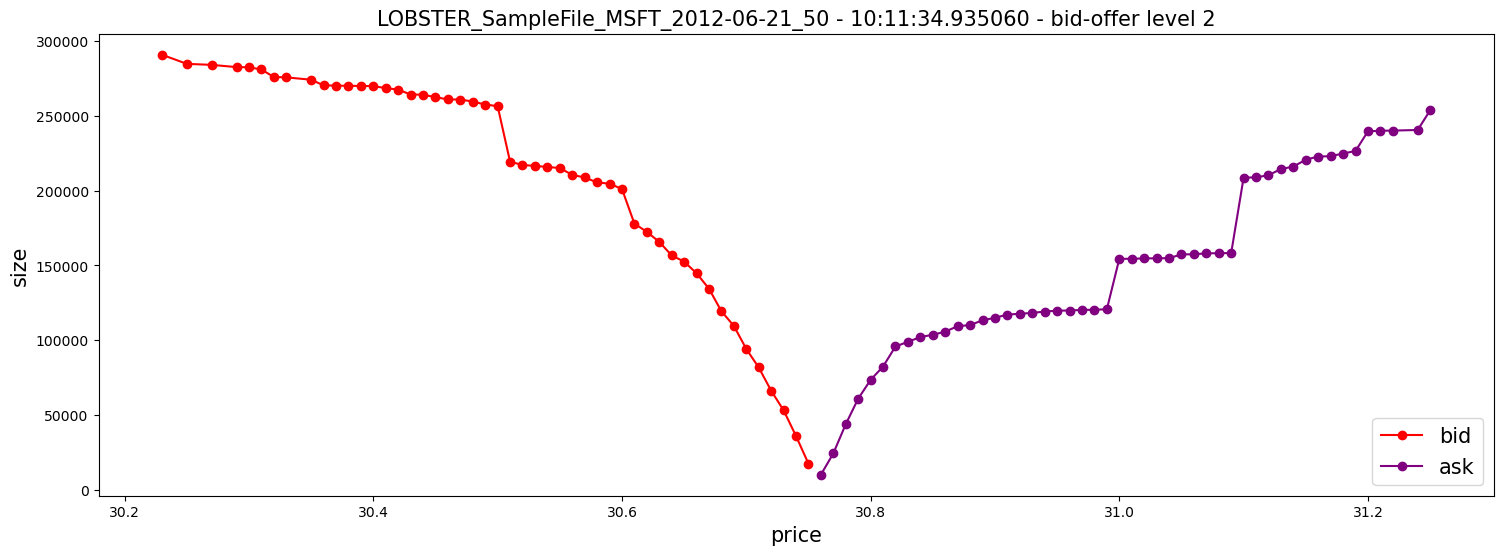

range = 0.4800000000000004


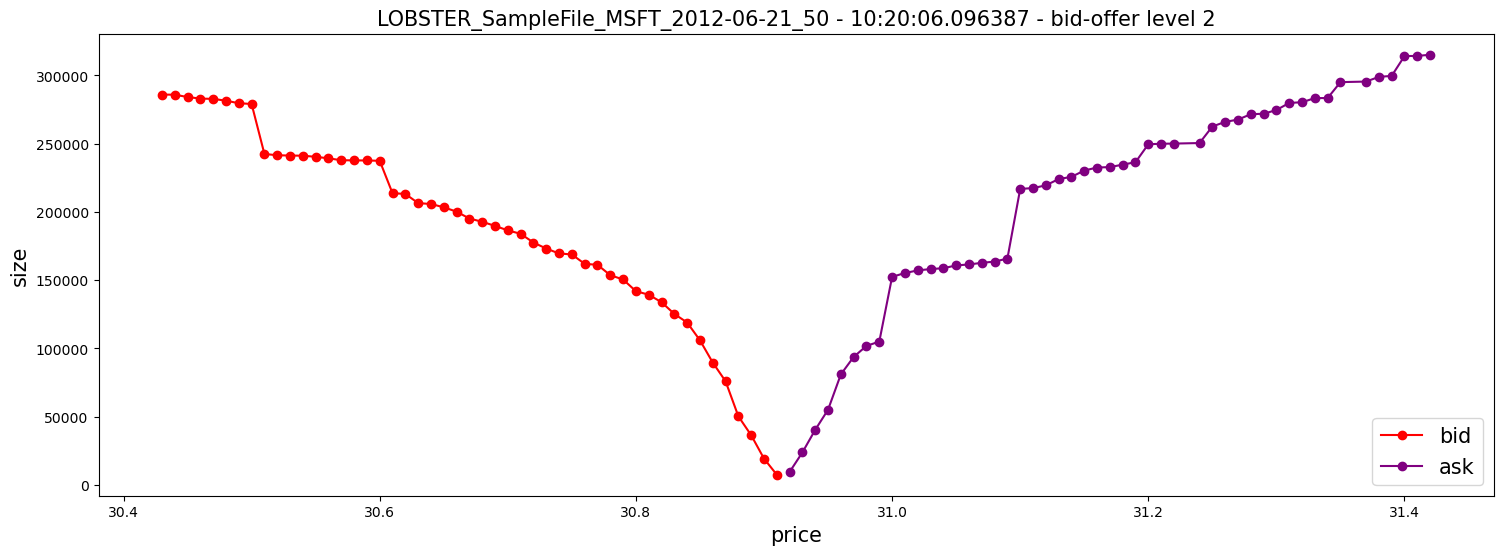

range = 0.5300000000000011


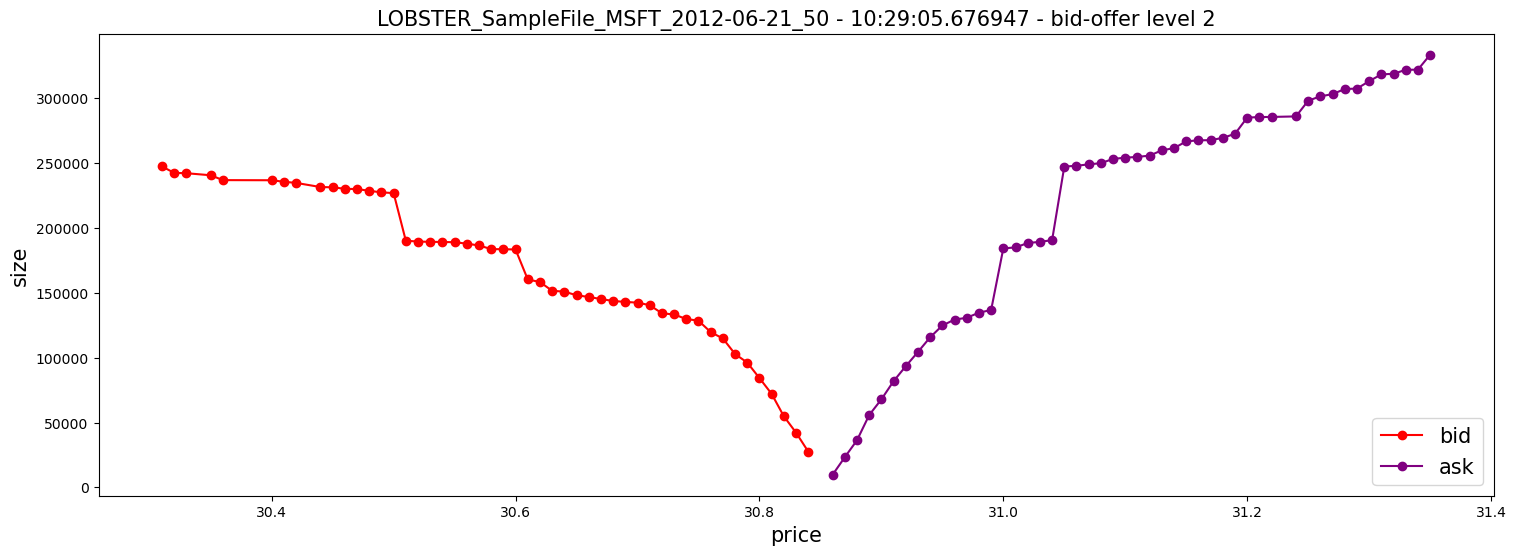

In [4]:
def get_bid_ask(bk):
    # trim each series to eliminate nulls padding each series
    ask, ask_size = np.array([(a/10000,s) for a,s in zip(bk[0::4], bk[1::4]) if s > 0]).T
    bid, bid_size = np.array([(b/10000,s) for b,s in zip(bk[2::4], bk[3::4]) if s > 0]).T
    
    # the last entries also need to be removed
    ask, ask_size, bid, bid_size = ask[:-1], ask_size[:-1], bid[:-1], bid_size[:-1]

    return ask, ask_size, bid, bid_size

for i,bk in book[10:150011:20000].iterrows():
    ask, ask_size, bid, bid_size = get_bid_ask(bk)

    print(f"range = {max(bid) - min(bid)}")

    plt.figure(figsize=(18,6))
    plt.plot(bid, np.cumsum(bid_size),'o-', color='red', label='bid')
    plt.plot(ask, np.cumsum(ask_size), 'o-',color='purple', label='ask')
    plt.title(f"{dir1} - { msg_time[i]} - bid-offer level 2", fontsize=15)
    plt.xlabel("price",fontsize=15)
    plt.ylabel("size", fontsize=15)
    plt.legend(loc='lower right',fontsize=15)
    plt.show()

In [5]:
pickle.dump({"ask":ask, "ask size":ask_size, "bid":bid, "bid size":bid_size}, open("bid_ask_snapshot.pkl",'wb'))

In [6]:
class get_depth():
    def __init__(self, min_size):
        self.size = min_size
        
    def bid_ask(self, side, side_size):
        try:
            ba = [a for a,s in zip(side, np.cumsum(side_size)) if s > self.size][0]
            return ba
        except:
#             print("book too small")
#             print(side, side_size)
            pass
    
    def bid_ask_stats(self, bk):
        ask, ask_size, bid, bid_size = get_bid_ask(bk)
        ask_depth = self.bid_ask(ask, ask_size)
        bid_depth = self.bid_ask(bid, bid_size)
        return {"ask":ask[0], "bid":bid[0], "ask depth":ask_depth, "bid depth":bid_depth}

print(datetime.now())
order_size = 100000   # 
depth = get_depth(order_size)

market_depth = pd.DataFrame([depth.bid_ask_stats(bk) for i,bk in book.iterrows()])

2026-03-15 12:24:23.351137


# plot the bid-ask spread and market depth over time

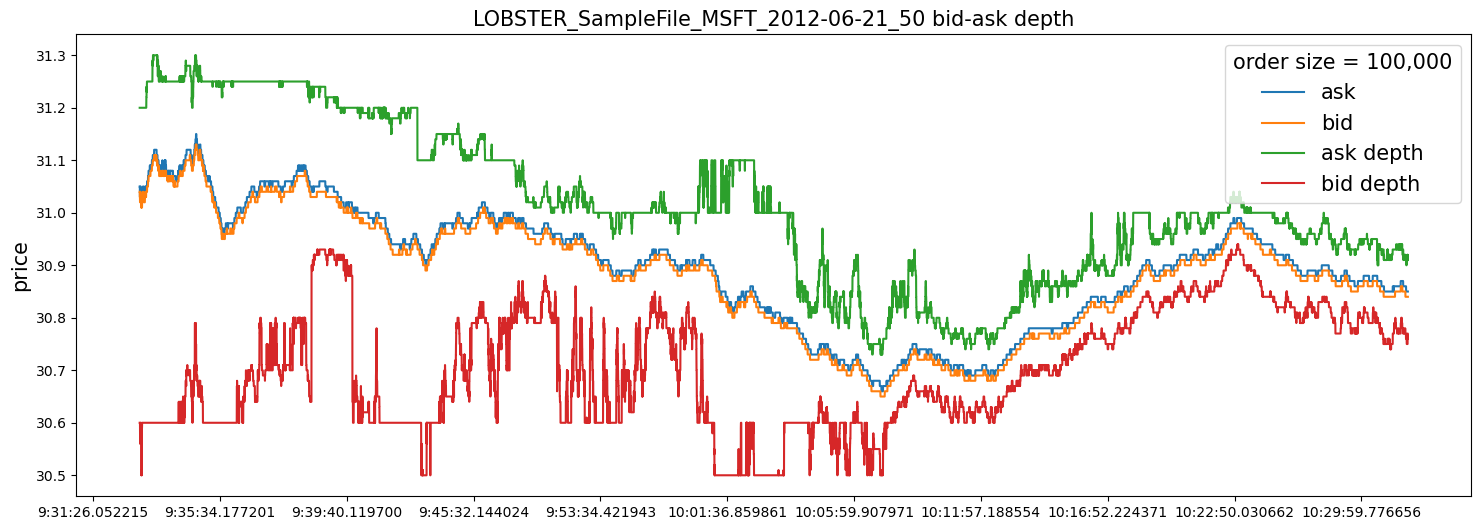

2026-03-15 12:25:39.045275


In [7]:
plt.figure(figsize=(18,6))
plt.plot(market_depth[5000:], label=market_depth.columns)
npoints = len(msg_time) - 5000
ticks = list(np.arange(0,npoints,int(npoints/10)))
plt.xticks(ticks, [msg_time[t + 5000] for t in ticks])
plt.title(f"{dir1} bid-ask depth",fontsize=15)
plt.ylabel("price", fontsize=15)
plt.legend(title=f"order size = {order_size:,}",title_fontsize=15, fontsize=15)
plt.show()

print(datetime.now())        

In [8]:
for c in msg.columns:
    counts = Counter(msg[c]).most_common()

    if len(counts) < 10:
        print(c, len(counts), ' : ', counts)
    else:
        print(c, len(counts))

time 127646
type 5  :  [(1, 69946), (3, 63528), (4, 6559), (2, 868), (5, 606)]
orderid 70007
size 933
price 207
direction 2  :  [(-1, 72640), (1, 68867)]


In [10]:
print(book[10:150011:20000].shape)
book[10:150011:20000]

(8, 200)


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
10,309900,3788,309500,300,310300,100,309300,3986,310400,100,...,-9999999999,0,9999999999,0,-9999999999,0,9999999999,0,-9999999999,0
20010,310500,9196,310300,2800,310600,5200,310200,3900,310700,3600,...,305000,42805,315500,3300,304900,467,315600,21776,304800,1100
40010,309800,3844,309700,1247,309900,8100,309600,2936,310000,5397,...,304900,467,314800,3510,304800,1726,314900,1664,304700,1250
60010,309200,9800,309100,12054,309300,12628,309000,21172,309400,9621,...,303600,730,314200,582,303500,3747,314400,950,303300,1580
80010,307200,4850,307100,7194,307300,15150,307000,10012,307400,11350,...,301700,2200,312000,13127,301600,500,312100,400,301500,1130
100010,307600,10120,307500,17522,307700,14263,307400,18426,307800,19510,...,302500,686,312500,13116,302300,6100,312600,3386,302200,100
120010,309200,9548,309100,7505,309300,14336,309000,11804,309400,16542,...,304400,1700,314200,882,304300,100,314400,950,304200,3928
140010,308600,9740,308400,27589,308700,13504,308300,14610,308800,13078,...,303200,258,313500,11500,303100,5000,313700,415,303000,1400
